# ASTR 5820 Problem Set 1

## 2. Reference Core

In [11]:
import numpy as np
from astrotools.cloud import collapse
import astrotools.constants as c

T = 10  # K
nH2 = 1e11  # m^-3
M = 3 * c.M_SUN  # kg

jeans_mass = collapse.jeans_mass(T, collapse.number_density_to_mass_density(nH2))

sound_speed = np.sqrt(c.K_B * T / (2.33 * c.M_H))
jeans_length = sound_speed * np.sqrt(np.pi / (c.G * collapse.number_density_to_mass_density(nH2)))

free_fall_time = collapse.free_fall_time(collapse.number_density_to_mass_density(nH2))

print(f"Jeans mass = {jeans_mass:.3g} kg")
print(f"Jeans length = {jeans_length:.3g} m")
print(f"Free-fall time = {free_fall_time:.3g} s = {free_fall_time / (3600 * 24 * 365):.3g} years")
print(f"M_J / M = {jeans_mass / M:.3g}")


Jeans mass = 3.08e+30 kg
Jeans length = 1.89e+15 m
Free-fall time = 3.07e+12 s = 9.73e+04 years
M_J / M = 0.517


From our results, we can see that the Jeans mass is smaller than the mass of the core which means it must be unstable. Additionally, we see that we can use $M_J/M$ as a parameter to determine the stability of a core. When it is smaller than 1, a core is unstable; and vice versa.

## 3. Characteristic Mass
#### Part 1

In [ ]:
import pandas as pd

data_location = '../../data/herschel_core_catalog.csv'

all_data = pd.read_csv(data_location)
filtered_data = []

for row in all_data.itertuples():
    if row.core_type != 'prestellar':
        continue
    name = row.name
    mass = row.M_core_msun * c.M_SUN  # Convert to kg
    radius = row.R_deconv_pc * c.PC  # Convert to meters
    temperature = row.T_dust_K
    number_density = row.n_H2_avd_cm3 * 1e6  # Convert to m^-3
    no_sed_fit = row.no_sed_fit

    jeans_mass = collapse.jeans_mass(temperature, collapse.number_density_to_mass_density(number_density))
    filtered_data.append({
            'name': name,
            'mass (kg)': mass,
            'radius (m)': radius,
            'temperature (K)': temperature,
            'number density (m^-3)': number_density,
            'jeans mass (kg)': jeans_mass,
            'no_sed_fit': no_sed_fit
        })

filtered_data_df = pd.DataFrame(filtered_data)
filtered_data_df

,name,mass (kg),radius (m),temperature (K),number density (m^-3),jeans mass (kg),no_sed_fit
0,182303.8-032358,2.187251e+29,6.171355e+14,11.5,3.600000e+10,6.337860e+30,1
1,182320.8-030539,1.988410e+29,5.862787e+14,11.5,3.500000e+10,6.427763e+30,1
2,182325.5-030410,1.332235e+30,1.049130e+15,9.6,4.500000e+10,4.323622e+30,0
3,182331.8-030327,4.235313e+30,2.345115e+15,9.8,1.200000e+10,8.635662e+30,0
4,182345.6-025551,1.332235e+30,1.326841e+15,9.8,2.300000e+10,6.237669e+30,0
...,...,...,...,...,...,...,...
464,183650.2-021455,6.959435e+29,7.405626e+14,11.2,6.500000e+10,4.533332e+30,0
465,183652.5-021914,3.380297e+29,1.049130e+15,13.5,1.100000e+10,1.458315e+31,0
466,183652.9-021440,3.976820e+29,6.479923e+14,10.6,6.000000e+10,4.344405e+30,0
467,183654.2-021242,4.374502e+29,6.171355e+14,11.1,7.200000e+10,4.249769e+30,0


#### Part 2

0.22758459260747882


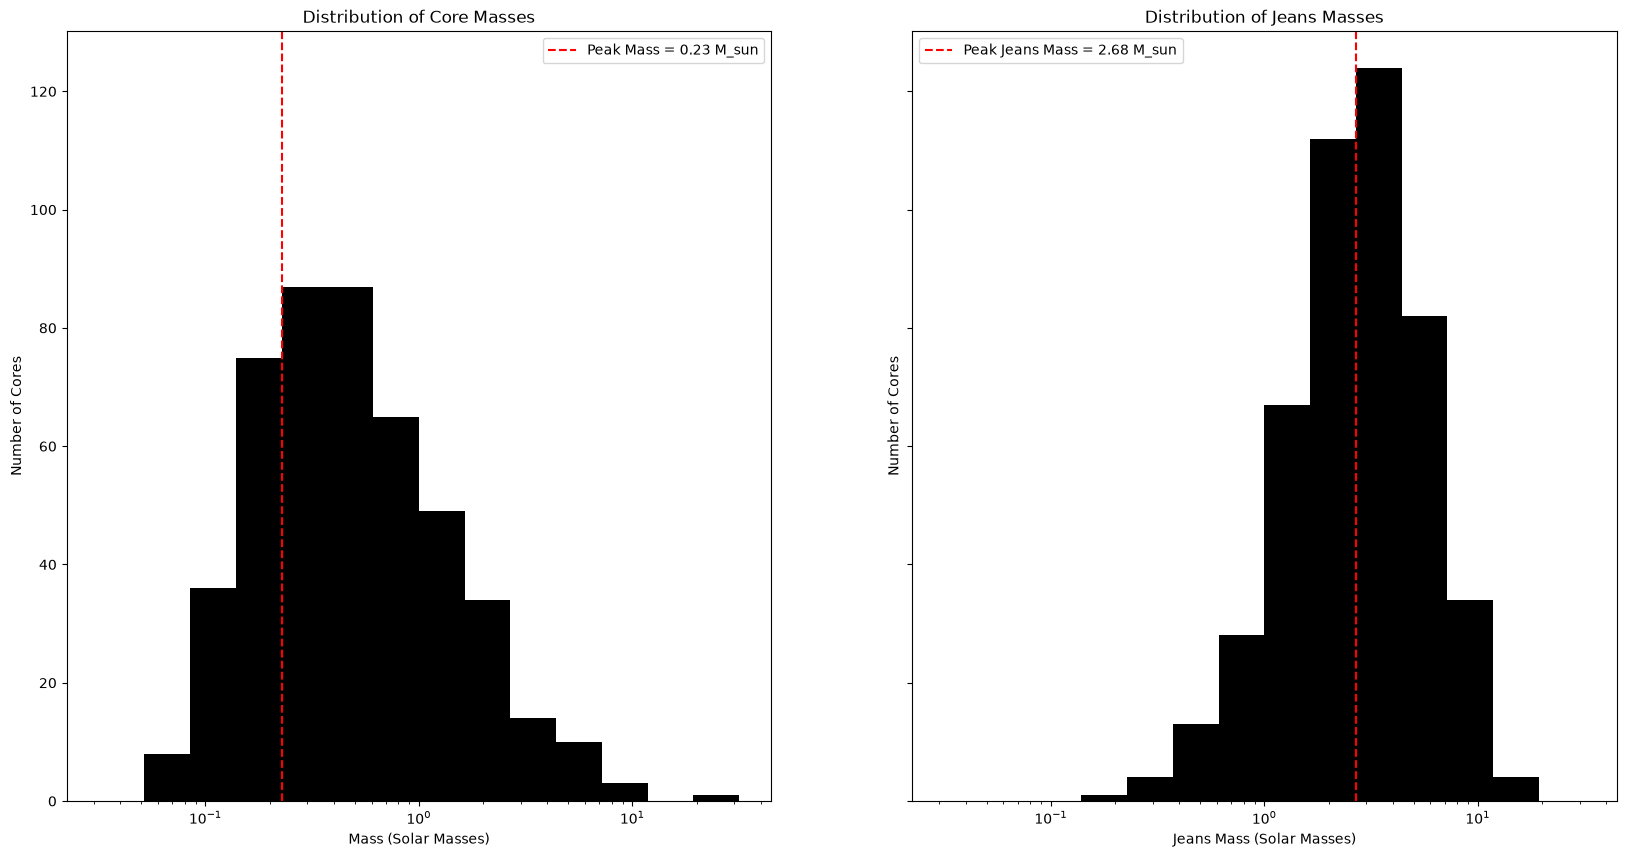

In [44]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 10), sharey = True)
ax[0].set_xscale('log')
ax[1].set_xscale('log')

ax[0].hist(filtered_data_df['mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15), color = 'black')
ax[0].set_xlabel('Mass (Solar Masses)')
ax[0].set_ylabel('Number of Cores')
ax[0].set_title('Distribution of Core Masses')

peak_mass = np.histogram(filtered_data_df['mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15))[1][np.histogram(filtered_data_df['mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15))[0].argmax()]
print(peak_mass)
ax[0].axvline(peak_mass, color = 'red', linestyle = '--', label = 'Peak Mass = {:.2f} M_sun'.format(peak_mass))
ax[0].legend()

ax[1].hist(filtered_data_df['jeans mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15), color = 'black')
ax[1].set_xlabel('Jeans Mass (Solar Masses)')
ax[1].set_ylabel('Number of Cores')
ax[1].set_title('Distribution of Jeans Masses')

peak_jeans_mass = np.histogram(filtered_data_df['jeans mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15))[1][np.histogram(filtered_data_df['jeans mass (kg)']/c.M_SUN, range = (10**(-1.5), 10**(1.5)), bins = np.logspace(-1.5, 1.5, 15))[0].argmax()]
ax[1].axvline(peak_jeans_mass, color = 'red', linestyle = '--', label = 'Peak Jeans Mass = {:.2f} M_sun'.format(peak_jeans_mass))
ax[1].legend()


#### Part 3

In [45]:
print(f"Peak Mass = {peak_mass:.3g} M_sun")
print(f"Peak Jeans Mass = {peak_jeans_mass:.3g} M_sun")
print(f"Peak Mass / Peak Jeans Mass = {peak_mass / peak_jeans_mass:.3g}")

print(f"Median Mass = {np.median(filtered_data_df['mass (kg)']/c.M_SUN):.3g} M_sun")
print(f"Median Jeans Mass = {np.median(filtered_data_df['jeans mass (kg)']/c.M_SUN):.3g} M_sun")
print(f"Median Mass / Median Jeans Mass = {np.median(filtered_data_df['mass (kg)']/c.M_SUN) / np.median(filtered_data_df['jeans mass (kg)']/c.M_SUN):.3g}")

Peak Mass = 0.228 M_sun
Peak Jeans Mass = 2.68 M_sun
Peak Mass / Peak Jeans Mass = 0.0848
Median Mass = 0.42 M_sun
Median Jeans Mass = 2.75 M_sun
Median Mass / Median Jeans Mass = 0.153


#### Part 1
We can see that the prediction misses by a factor of ~10! The peak Jeans mass is much larger than the peak core mass from the data set. This is also reflected when comparing the median mass in the data set and the median Jeans mass ad they are also off by a factor of ~10. This clearly points towards collapse not being monolithic, and more specifically, it seems as though the expected number of cores formed would be around 10.

#### Part 2
From this data, it seems as though the core mass function is essentially the same as the initial mass function as the former's peak is within the 0.2-0.3 solar masses range. This is not consistent with the 30%-50% efficiency.


## 4. Collapse Timescale

Mean ratio t_life / t_ff = 2.27


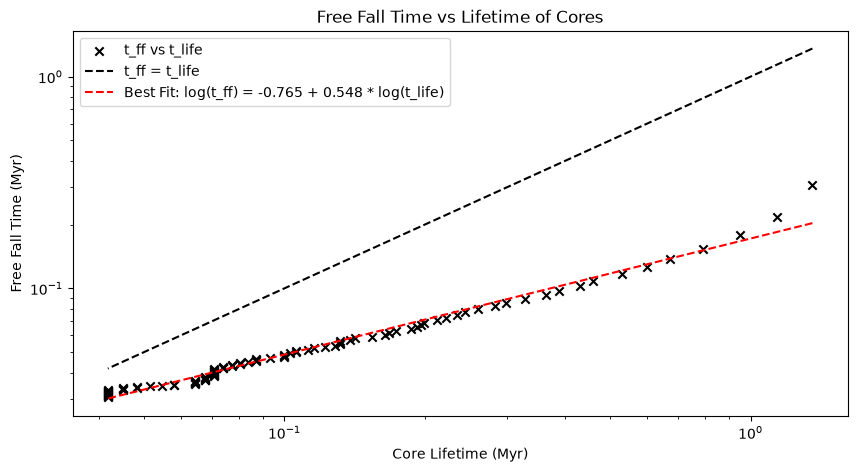

In [72]:
density_thresholds = np.linspace(1e10, 1e12, 100)
t_life = []
t_ff = []

for threshold in density_thresholds:
    filtered_data_df_threshold = filtered_data_df[filtered_data_df['number density (m^-3)'] > threshold]
    t_life.append(len(filtered_data_df_threshold) * 2 / 622)
    t_ff.append(collapse.free_fall_time(collapse.number_density_to_mass_density(threshold))/(3600 * 24 * 365 * 1e6))

fit = np.polyfit(np.log10(t_life), np.log10(t_ff), 1)

plt.figure(figsize = (10, 5))
plt.scatter(t_life, t_ff, color = 'black', label = 't_ff vs t_life', marker = 'x')
plt.loglog(t_life, t_life, linestyle = '--', color = 'black', label = 't_ff = t_life')
plt.loglog(t_life, 10**fit[1] * np.array(t_life)**fit[0], linestyle = '--', color = 'red', label = 'Best Fit: log(t_ff) = {:.3g} + {:.3g} * log(t_life)'.format(fit[1], fit[0]))
plt.legend()
plt.xlabel('Core Lifetime (Myr)')
plt.ylabel('Free Fall Time (Myr)')
plt.title('Free Fall Time vs Lifetime of Cores')

print('Mean ratio t_life / t_ff = {:.3g}'.format(np.mean(np.asarray(t_life)/np.asarray(t_ff))))

#### Part 1
If the slope was equal to one, we would know that both of these timescales scale equally with density. However, since t_life changes faster than t_ff as shown with the slope of 0.548, we know that t_life calculations are more sensitive to changes in density across all the thresholds we tested.

#### Part 2
The ratio is ~2 so the cores collapse two times slower than the free fall time. Free fall time is a lower bound for collapse time scales as we make various assumptions about how the collapse will occur. For instance, t_ff assumes a homologous collapse and not an inside-out collapse.

#### Part 3
In that case we would see a slope << 1 as the collapse timescales would be significantly longer than the free fall time.